# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_bike_sharing_dataset.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

/tmp/ipykernel_26110/2291428374.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['count'].resample('M').mean()


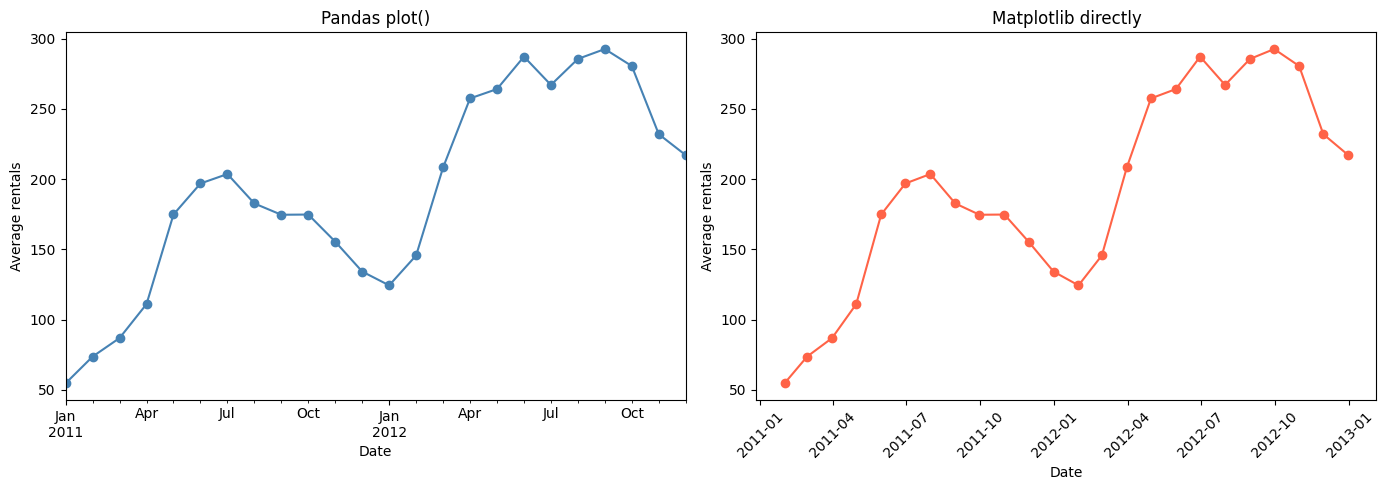

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Resample to monthly average
monthly_avg = df['count'].resample('M').mean()

# --- Method 1: Pandas DataFrame.plot() ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_avg.plot(ax=axes[0], marker='o', color='steelblue', title='Pandas plot()')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average rentals')

# --- Method 2: Pure Matplotlib ---
axes[1].plot(monthly_avg.index, monthly_avg.values, marker='o', color='tomato')
axes[1].set_title('Matplotlib directly')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average rentals')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Спостереження: чим відрізняються 2 графіки?
Обидва графіки відображають однакові дані — середню кількість оренд велосипедів по місяцях. Однак є відмінності:
 Pandas (DataFrame.plot()) — автоматично форматує вісь X з датами, підписує осі за замовчуванням, код коротший і зручніший для швидкого аналізу.
 Matplotlib безпосередньо вимагає більше коду, але дає повний контроль над кожним елементом графіка: кольором, розміром, підписами, сіткою тощо.
Який більше подобається? Особисто мені більше подобається Matplotlib, бо він гнучкіший і дозволяє робити графіки більш кастомізованими та професійними.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [7]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

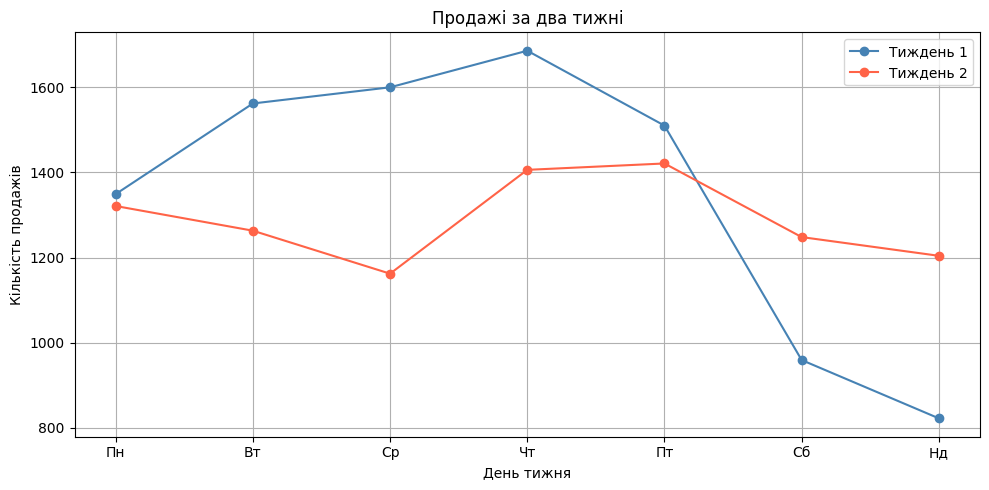

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Дані
days = [1, 2, 3, 4, 5, 6, 7]  # 1 - це понеділок
sales_week1 = [1349, 1562, 1600, 1686, 1510, 959, 822]
sales_week2 = [1321, 1263, 1162, 1406, 1421, 1248, 1204]

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']

plt.figure(figsize=(10, 5))
plt.plot(day_names, sales_week1, marker='o', color='steelblue', label='Тиждень 1')
plt.plot(day_names, sales_week2, marker='o', color='tomato', label='Тиждень 2')

plt.title('Продажі за два тижні')
plt.xlabel('День тижня')
plt.ylabel('Кількість продажів')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1. В який тиждень продажі були стабільніше?
Судячи з графіку, Тиждень 2 був стабільнішим. Лінія другого тижня є більш рівною — продажі тримаються приблизно в діапазоні 1162–1421. Натомість у Тижні 1 є різкий спад у суботу та неділю (959 і 822), що свідчить про велику нестабільність.

In [9]:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print(f"Стандартне відхилення Тиждень 1: {std_week1:.1f}")
print(f"Стандартне відхилення Тиждень 2: {std_week2:.1f}")

Стандартне відхилення Тиждень 1: 311.1
Стандартне відхилення Тиждень 2: 90.9


Висновок: Чим менше стандартне відхилення, тим стабільніші продажі. Тиждень 2 майже втричі стабільніший

import matplotlib.pyplot as plt
import numpy as np

# Дані
days = [1, 2, 3, 4, 5, 6, 7]  # 1 - це понеділок
sales_week1 = [1349, 1562, 1600, 1686, 1510, 959, 822]
sales_week2 = [1321, 1263, 1162, 1406, 1421, 1248, 1204]

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']

plt.figure(figsize=(10, 5))
plt.plot(day_names, sales_week1, marker='o', color='steelblue', label='Тиждень 1')
plt.plot(day_names, sales_week2, marker='o', color='tomato', label='Тиждень 2')

plt.title('Продажі за два тижні')
plt.xlabel('День тижня')
plt.ylabel('Кількість продажів')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

/tmp/ipykernel_26110/2729527234.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df['temp'].resample('M').mean()


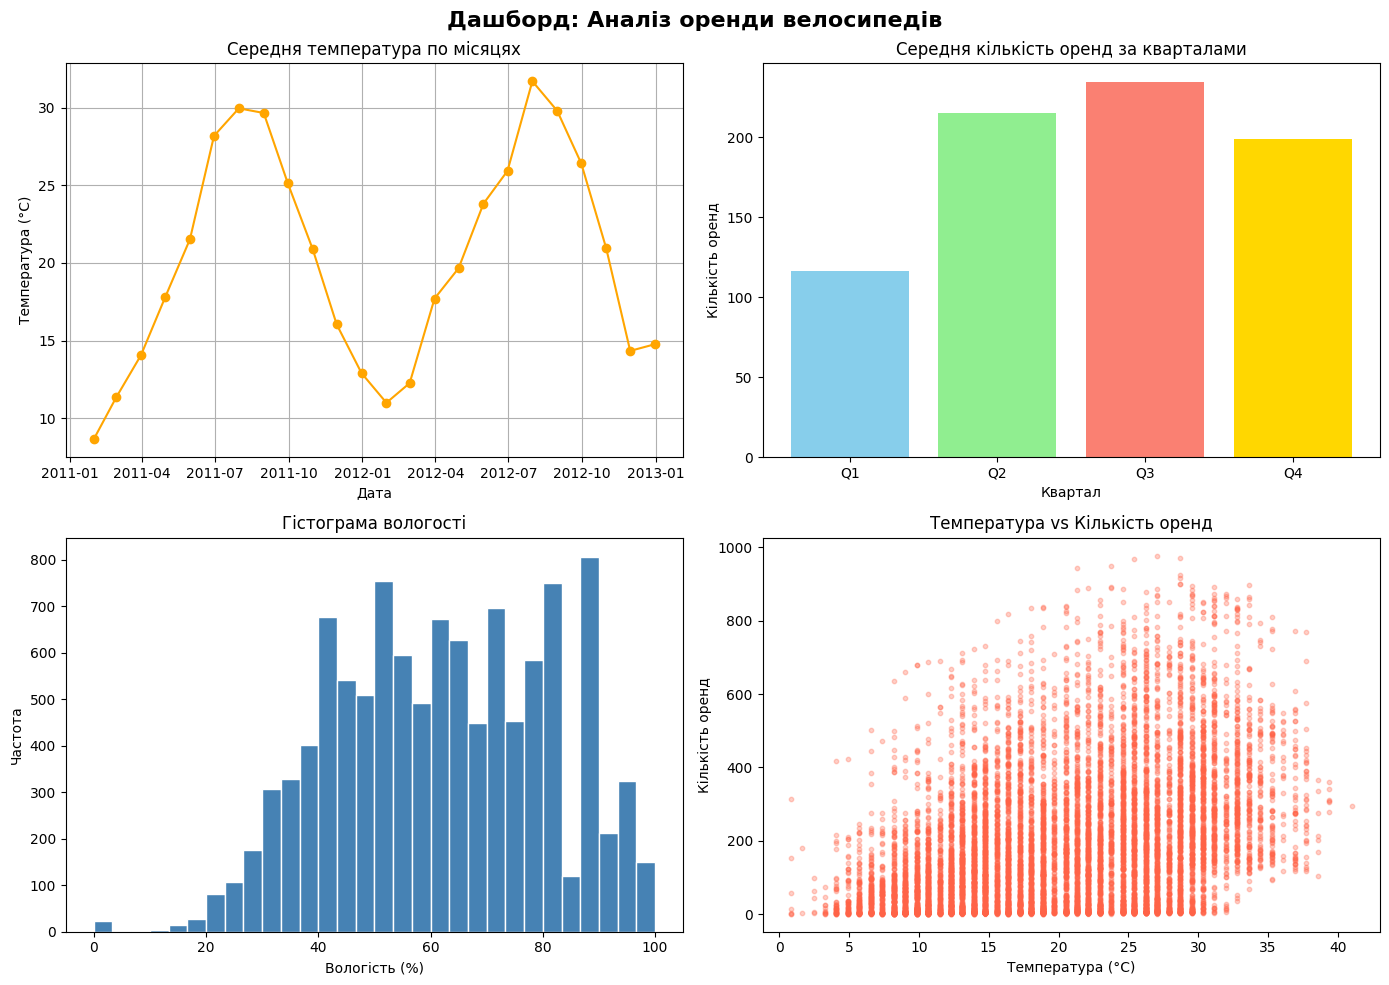

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Дашборд: Аналіз оренди велосипедів', fontsize=16, fontweight='bold')

# 1. Лінійний графік середньої температури помісячно
monthly_temp = df['temp'].resample('M').mean()
axes[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='orange')
axes[0, 0].set_title('Середня температура по місяцях')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Температура (°C)')
axes[0, 0].grid(True)

# 2. Стовпчикова діаграма середньої кількості оренд за кварталами
quarterly_avg = df.groupby('season')['count'].mean()
season_names = ['Q1', 'Q2', 'Q3', 'Q4']
axes[0, 1].bar(season_names, quarterly_avg.values, color=['skyblue','lightgreen','salmon','gold'])
axes[0, 1].set_title('Середня кількість оренд за кварталами')
axes[0, 1].set_xlabel('Квартал')
axes[0, 1].set_ylabel('Кількість оренд')

# 3. Гістограма вологості
axes[1, 0].hist(df['humidity'], bins=30, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Гістограма вологості')
axes[1, 0].set_xlabel('Вологість (%)')
axes[1, 0].set_ylabel('Частота')

# 4. Scatter plot температури vs кількості оренд
axes[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='tomato', s=10)
axes[1, 1].set_title('Температура vs Кількість оренд')
axes[1, 1].set_xlabel('Температура (°C)')
axes[1, 1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

/tmp/ipykernel_26110/2816563430.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df['temp'].resample('M').mean()


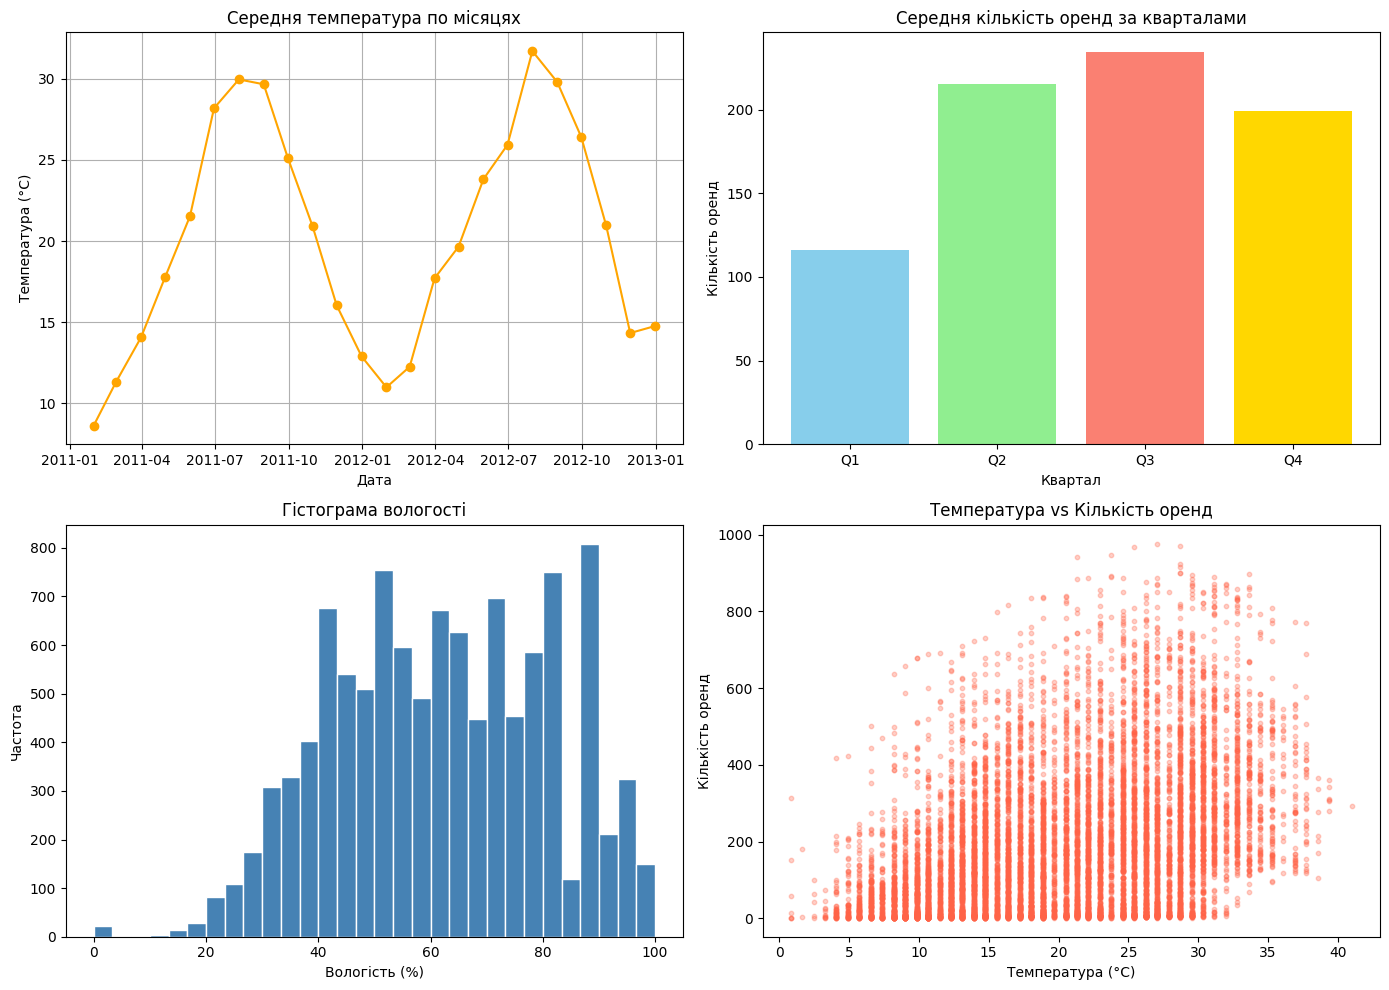

In [14]:
ig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Дашборд (OOP підхід)', fontsize=16, fontweight='bold')

# 1. Лінійний графік середньої температури помісячно
monthly_temp = df['temp'].resample('M').mean()
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='orange')
ax[0, 0].set_title('Середня температура по місяцях')
ax[0, 0].set_xlabel('Дата')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True)

# 2. Стовпчикова діаграма за кварталами
quarterly_avg = df.groupby('season')['count'].mean()
ax[0, 1].bar(['Q1','Q2','Q3','Q4'], quarterly_avg.values,
             color=['skyblue','lightgreen','salmon','gold'])
ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Кількість оренд')

# 3. Гістограма вологості
ax[1, 0].hist(df['humidity'], bins=30, color='steelblue', edgecolor='white')
ax[1, 0].set_title('Гістограма вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')

# 4. Scatter plot
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='tomato', s=10)
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

Різниця від Завдання 3 — тільки те, що використовуємо ax[0,0] замість axes[0,0]. Результат ідентичний попередньому дашборду.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

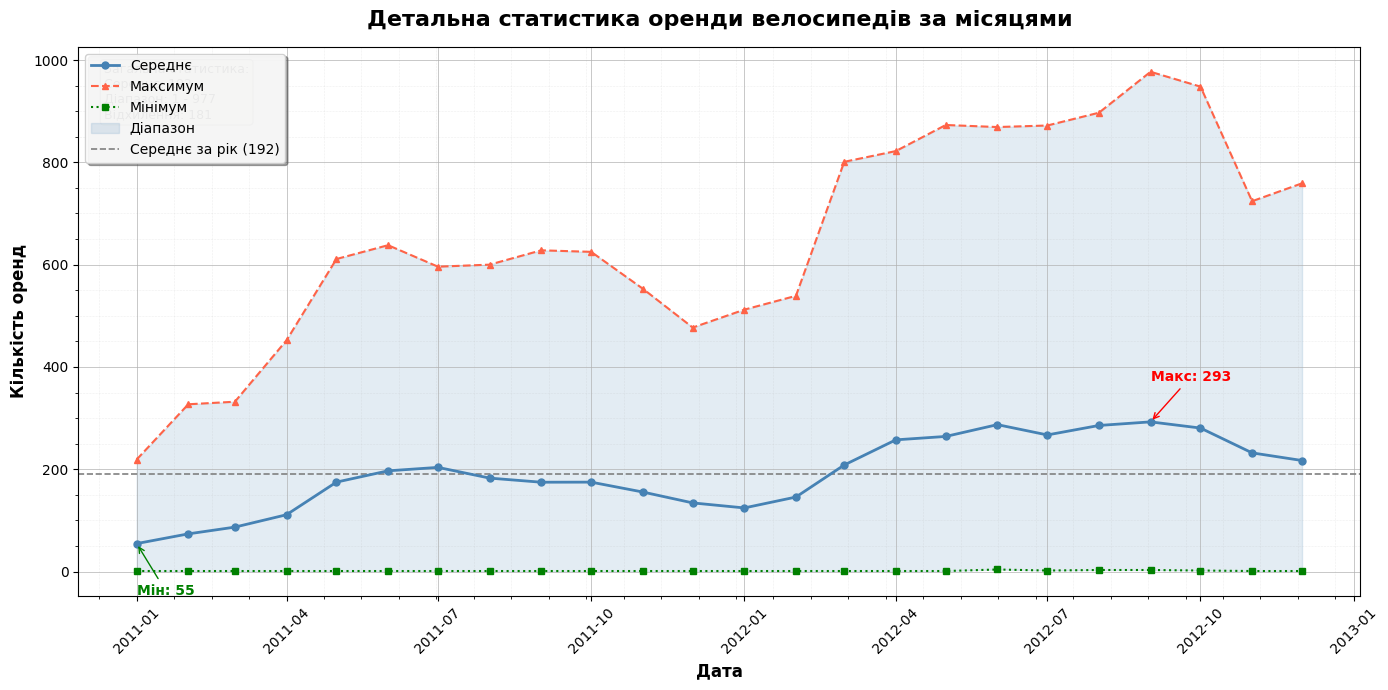

In [15]:
# Підготовка даних
monthly = df.groupby(df.index.to_period('M'))['count'].agg(['mean', 'max', 'min'])
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 7))

# 1. Три лінії: середнє, максимум, мінімум
ax.plot(monthly.index, monthly['mean'], color='steelblue', linewidth=2,
        marker='o', markersize=5, label='Середнє', zorder=3)
ax.plot(monthly.index, monthly['max'], color='tomato', linewidth=1.5,
        linestyle='--', marker='^', markersize=5, label='Максимум')
ax.plot(monthly.index, monthly['min'], color='green', linewidth=1.5,
        linestyle=':', marker='s', markersize=5, label='Мінімум')

# 2. Заливка між мінімумом та максимумом
ax.fill_between(monthly.index, monthly['min'], monthly['max'],
                alpha=0.15, color='steelblue', label='Діапазон')

# 3. Горизонтальна лінія середнього за весь рік
overall_mean = df['count'].mean()
ax.axhline(overall_mean, color='gray', linestyle='--',
           linewidth=1.2, label=f'Середнє за рік ({overall_mean:.0f})')

# 4. Дві анотації: найвище та найнижче середнє
max_idx = monthly['mean'].idxmax()
min_idx = monthly['mean'].idxmin()

ax.annotate(f"Макс: {monthly['mean'].max():.0f}",
            xy=(max_idx, monthly['mean'].max()),
            xytext=(max_idx, monthly['mean'].max() + 80),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

ax.annotate(f"Мін: {monthly['mean'].min():.0f}",
            xy=(min_idx, monthly['mean'].min()),
            xytext=(min_idx, monthly['mean'].min() - 100),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green', fontweight='bold')

# 5. Двошарова сітка
ax.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)
ax.minorticks_on()

# 6. Стилізована легенда з тінню
ax.legend(loc='upper left', framealpha=0.9, shadow=True, fontsize=10)

# 7. Текстовий блок зі статистикою
stats_text = (f"Загальна статистика:\n"
              f"Середнє: {overall_mean:.0f}\n"
              f"Діапазон: {df['count'].min()} - {df['count'].max()}\n"
              f"Відхилення: {df['count'].std():.0f}")

ax.text(0.02, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8))

# 8. Професійне оформлення
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Дата', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Яка перевага додавання анотацій на графік?
Анотації дозволяють одразу звернути увагу читача на ключові точки даних — наприклад, на максимум (293) та мінімум (55) — без необхідності самостійно шукати їх на графіку. Це робить графік більш інформативним і зрозумілим, особливо для презентацій або звітів, де читач не знайомий з даними.
2. Для чого використовується fill_between()?
fill_between() заповнює область між двома лініями кольором. У нашому випадку — між мінімумом та максимумом. Це наочно показує діапазон розкиду даних: чим ширша заливка, тим більша нестабільність. Це набагато наочніше, ніж просто дві окремі лінії.
3. Як текстовий блок допомагає в інтерпретації даних?
Текстовий блок зі статистикою (середнє, діапазон, відхилення) розміщений прямо на графіку — читачу не потрібно шукати ці цифри окремо в таблицях або тексті. Це економить час і робить графік самодостатнім: він містить і візуалізацію, і числові висновки одночасно